# Cardiovascular risks calculation and classification 

This dataset was synthetically generated and may not reflect real-world data. It contains 30,000 records and 20 features related to individuals’ health conditions, along with some noisy/random columns.

I am particularely interested in developing knowledge on the associations between lifestyle and habits with our general health, especially when measured and illustrated using biomarkers. 
This work establishes, first of all, a cardiovascular risk score and classification, based on biomarkers metrics and their standard clinical thresholds. Then, I applied the same approach for the lifestyle metrics, in order to confront lifestyle and CV risk classifications, considering their strong relationship. 

Author : Youenn MARTIN

## Introduction

### Features Description

<b> Age </b> : Patient’s age (in years).  
<b> Gender </b> : Male / Female.  
<b> Medical Condition </b> : Reported health condition (e.g., Diabetes, Hypertension, Asthma, Obesity, Healthy).  
<b> Glucose </b> : Blood glucose level.  
<b> Blood Pressure </b> : Blood pressure measurement.  
<b> BMI </b> : Body Mass Index.  
<b> Oxygen Saturation </b> : Blood oxygen saturation level.  
<b> LengthOfStay </b> : Hospital length of stay (days).  
<b> Cholesterol </b> : Cholesterol level.  
<b> Triglycerides </b> : Triglyceride level.  
<b> HbA1c </b> : Hemoglobin A1c (glycated hemoglobin).  
<b> Smoking </b> : Smoking status (0 = Non-smoker, 1 = Smoker).  
<b> Alcohol </b> : Alcohol consumption (0 = No, 1 = Yes).  
<b> Physical Activity </b> : Physical activity (approx. hours/week).    
<b> Diet Score </b> : Diet quality score (numeric).    
<b> Family History </b> : Family medical history (0 = No, 1 = Yes).  
<b> Stress Level </b> : Stress level (numeric scale).  
<b> Sleep Hours </b> : Average sleep hours per day.  
<b> random_notes </b> : Random notes (lorem / ipsum / ###).  
<b> noise_col </b> : Noise column (unrelated random values).  

### Import Libraries 

In [6]:
import pandas as pd
import requests
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.subplots as sp
import seaborn as sns
from io import StringIO
import os
import time
import os
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Import CSV

In [8]:
df = pd.read_csv('CV_risk_data.csv')
df

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,54.0,Female,Healthy,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71,ipsum,89.573837
29996,41.0,Male,Asthma,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81,lorem,-5.864517
29997,83.0,Female,NaN,NaN,170.11,30.55,97.83,3,210.13,168.76,5.05,0,0,4.53,4.50,0,4.31,3.61,###,-30.934595
29998,41.0,Male,Diabetes,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80,ipsum,5.085258


## Data Wranling

### Data Initial Exploration

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  str    
 2   Medical Condition  25500 non-null  str    
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       30000 non-null

In [12]:
df.isnull().sum().sort_values(ascending=False)

Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64

### Data Cleaning 

In [14]:
# Clean dataframe from NAs 
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.strip()
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 13355 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                13355 non-null  float64
 1   Gender             13355 non-null  str    
 2   Medical Condition  13355 non-null  str    
 3   Glucose            13355 non-null  float64
 4   Blood Pressure     13355 non-null  float64
 5   BMI                13355 non-null  float64
 6   Oxygen Saturation  13355 non-null  float64
 7   LengthOfStay       13355 non-null  int64  
 8   Cholesterol        13355 non-null  float64
 9   Triglycerides      13355 non-null  float64
 10  HbA1c              13355 non-null  float64
 11  Smoking            13355 non-null  int64  
 12  Alcohol            13355 non-null  int64  
 13  Physical Activity  13355 non-null  float64
 14  Diet Score         13355 non-null  float64
 15  Family History     13355 non-null  int64  
 16  Stress Level       13355 non-null  flo

In [15]:
# Drop unnecessary columns 
df.drop(columns=['random_notes', 'noise_col'], inplace=True)
df.describe()

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
count,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000,13355.000000
mean,54.621939,123.699637,140.257456,28.477885,94.920469,4.393635,212.938431,176.974248,6.297032,0.276151,0.239760,3.828392,4.041902,0.437739,5.900396,6.243131
std,15.884199,41.703479,21.085526,5.760367,3.752591,2.710919,33.738266,48.570712,1.326625,0.447109,0.426953,2.025940,1.819880,0.496127,2.214387,1.188671
min,10.000000,20.320000,74.240000,9.400000,67.510000,1.000000,95.730000,-8.140000,3.460000,0.000000,0.000000,-2.000000,-1.750000,0.000000,-2.070000,1.590000
25%,45.000000,96.240000,125.010000,24.580000,92.995000,3.000000,189.060000,141.520000,5.330000,0.000000,0.000000,2.370000,2.780000,0.000000,4.350000,5.420000
50%,55.000000,110.620000,138.110000,28.050000,95.250000,4.000000,211.680000,173.410000,5.970000,0.000000,0.000000,3.600000,3.800000,0.000000,5.870000,6.230000
75%,66.000000,137.050000,153.790000,31.810000,97.350000,5.000000,235.445000,208.420000,6.920000,1.000000,0.000000,5.100000,5.030000,1.000000,7.430000,7.080000
max,89.000000,318.510000,224.250000,52.860000,110.070000,19.000000,355.270000,421.510000,11.940000,1.000000,1.000000,12.410000,12.060000,1.000000,13.920000,10.350000


In [16]:
# Check for data outliers 
## Negative values
cleaned_df = df[(df['Physical Activity'] > 0) & (df['Diet Score'] > 0) & (df['Stress Level'] > 0) & (df['Triglycerides'] > 20) & (df['BMI'] > 10)]
cleaned_df.describe()

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
count,13136.000000,13136.000000,13136.00000,13136.000000,13136.00000,13136.000000,13136.000000,13136.00000,13136.000000,13136.000000,13136.000000,13136.000000,13136.000000,13136.000000,13136.000000,13136.000000
mean,54.643879,123.399214,140.24920,28.439493,94.91914,4.386038,212.897240,176.85072,6.285911,0.276188,0.240789,3.876439,4.066255,0.437348,5.914567,6.245250
std,15.922242,41.527224,21.12624,5.747889,3.75807,2.715285,33.774849,48.40635,1.320142,0.447128,0.427579,1.987480,1.807054,0.496078,2.195808,1.189709
min,10.000000,20.320000,74.24000,10.310000,67.51000,1.000000,95.730000,22.54000,3.460000,0.000000,0.000000,0.010000,0.050000,0.000000,0.020000,1.590000
25%,45.000000,96.190000,124.97750,24.550000,93.00000,3.000000,188.977500,141.43750,5.330000,0.000000,0.000000,2.410000,2.800000,0.000000,4.360000,5.420000
50%,55.000000,110.440000,138.11000,28.000000,95.25000,4.000000,211.615000,173.14000,5.960000,0.000000,0.000000,3.625000,3.815000,0.000000,5.880000,6.230000
75%,66.000000,136.337500,153.81250,31.780000,97.35250,5.000000,235.440000,208.26000,6.910000,1.000000,0.000000,5.130000,5.050000,1.000000,7.430000,7.080000
max,89.000000,318.510000,224.25000,52.860000,110.07000,19.000000,355.270000,388.99000,11.940000,1.000000,1.000000,12.410000,12.060000,1.000000,13.920000,10.350000


## Exploratory Data Analysis (EDA)

### Binary variables 

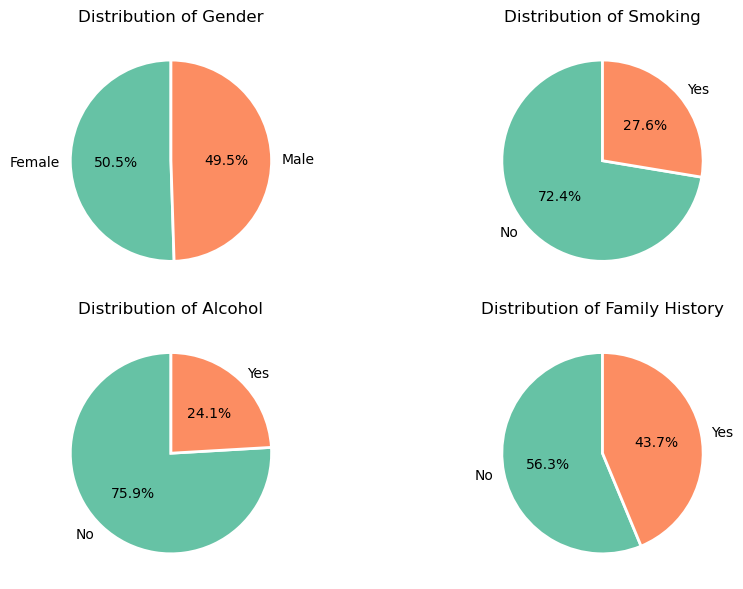

In [19]:
binary_vars = [col for col in cleaned_df.columns if cleaned_df[col].nunique() == 2]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

colors = ['#66c2a5', '#fc8d62'] 

for i, col in enumerate(binary_vars[:4]):
    counts = cleaned_df[col].value_counts()

    # labels management (0/1 -> No/Yes)
    if set(counts.index) == {0, 1}:
        labels = ['No', 'Yes']
        counts = counts.sort_index()  # assure 0 puis 1
    else:
        labels = counts.index

    axes[i].pie(
        counts,
        autopct='%1.1f%%',
        colors=colors[:len(counts)],
        startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        labels=labels,
        pctdistance=0.55
    )

    axes[i].set_title(f"Distribution of {col}", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

### Numerical variables

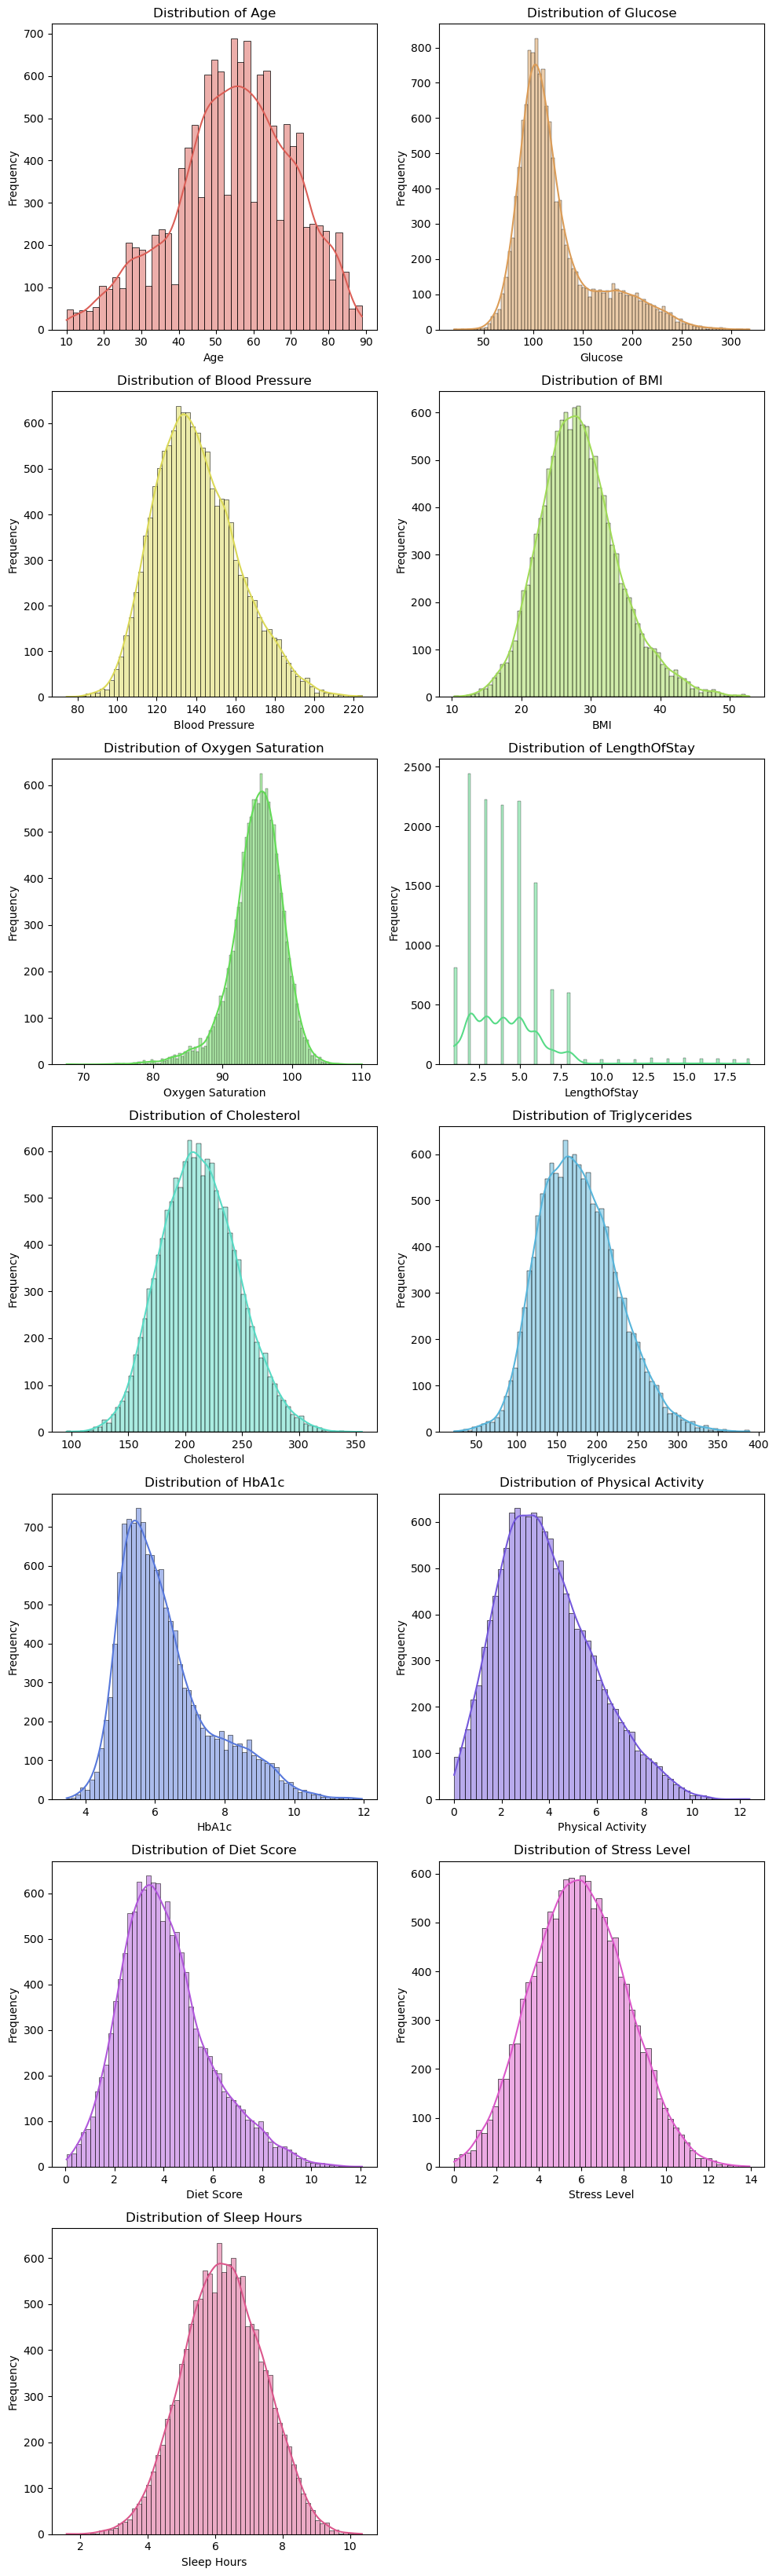

In [21]:
# Columns to be scaled (excluding binary and categorical)
categorical_vars = [col for col in df.columns if (df[col].nunique() < 11 and col not in binary_vars)]
cols2scale = [col for col in cleaned_df.columns if col not in binary_vars + categorical_vars]

# Combine columns to plot: numerical columns for histograms, categorical for bar plots
columns_to_plot = cols2scale

# Number of subplots
num_cols = len(columns_to_plot)
num_rows = (num_cols + 2) // 2  # This creates a grid with 2 columns

# Create the subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(10, num_rows * 4.7))
axes = axes.flatten()
colors = sns.color_palette("hls", num_cols)

# Loop through the columns to create histograms or bar plots
for i, col in enumerate(columns_to_plot):
    if col in categorical_vars:
        sns.countplot(x=col, data=cleaned_df, ax=axes[i], palette=[colors[i]])
    else:
        sns.histplot(cleaned_df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical variables (=Medical Condition)

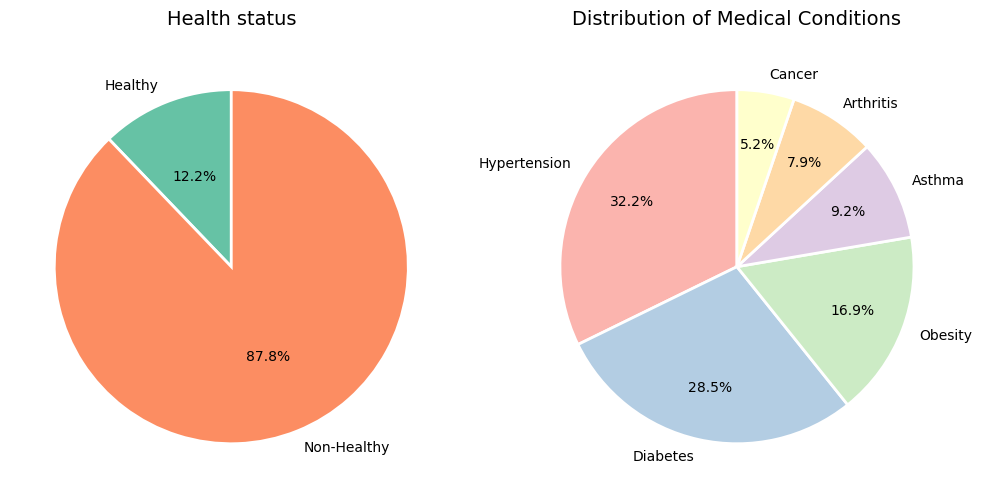

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 ligne, 2 colonnes
cleaned_df['Health Status'] = cleaned_df['Medical Condition'].apply(lambda x: 'Healthy' if x == 'Healthy' else 'Non-Healthy')

# Health Status
counts = cleaned_df['Health Status'].value_counts()
ordered_labels = ['Healthy', 'Non-Healthy']
ordered_counts = [counts.get('Healthy', 0), counts.get('Non-Healthy', 0)]

axes[0].pie(
    ordered_counts,
    autopct='%1.1f%%',
    colors=['#66c2a5', '#fc8d62'],
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    labels=ordered_labels,
    pctdistance=0.55
)
axes[0].set_title("Health status", fontsize=14, pad=15)

# Non-Healthy conditions
non_healthy = cleaned_df[cleaned_df['Medical Condition'] != 'Healthy']
counts_non_healthy = non_healthy['Medical Condition'].value_counts()

axes[1].pie(
    counts_non_healthy,
    autopct='%1.1f%%',
    colors=plt.cm.Pastel1(range(len(counts_non_healthy))),
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    labels=counts_non_healthy.index,
    pctdistance=0.70
)
axes[1].set_title("Distribution of Medical Conditions", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

### Bivariate Analyses 

C:\Users\33638\AppData\Local\Temp\ipykernel_13876\3359049843.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cleaned_df,x='Smoking',y='Stress Level',inner='box',palette='Set2',legend=True,ax=ax)
C:\Users\33638\AppData\Local\Temp\ipykernel_13876\3359049843.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cleaned_df,x='Alcohol',y='Physical Activity',inner='box',palette='Paired',legend=True,ax=ax)


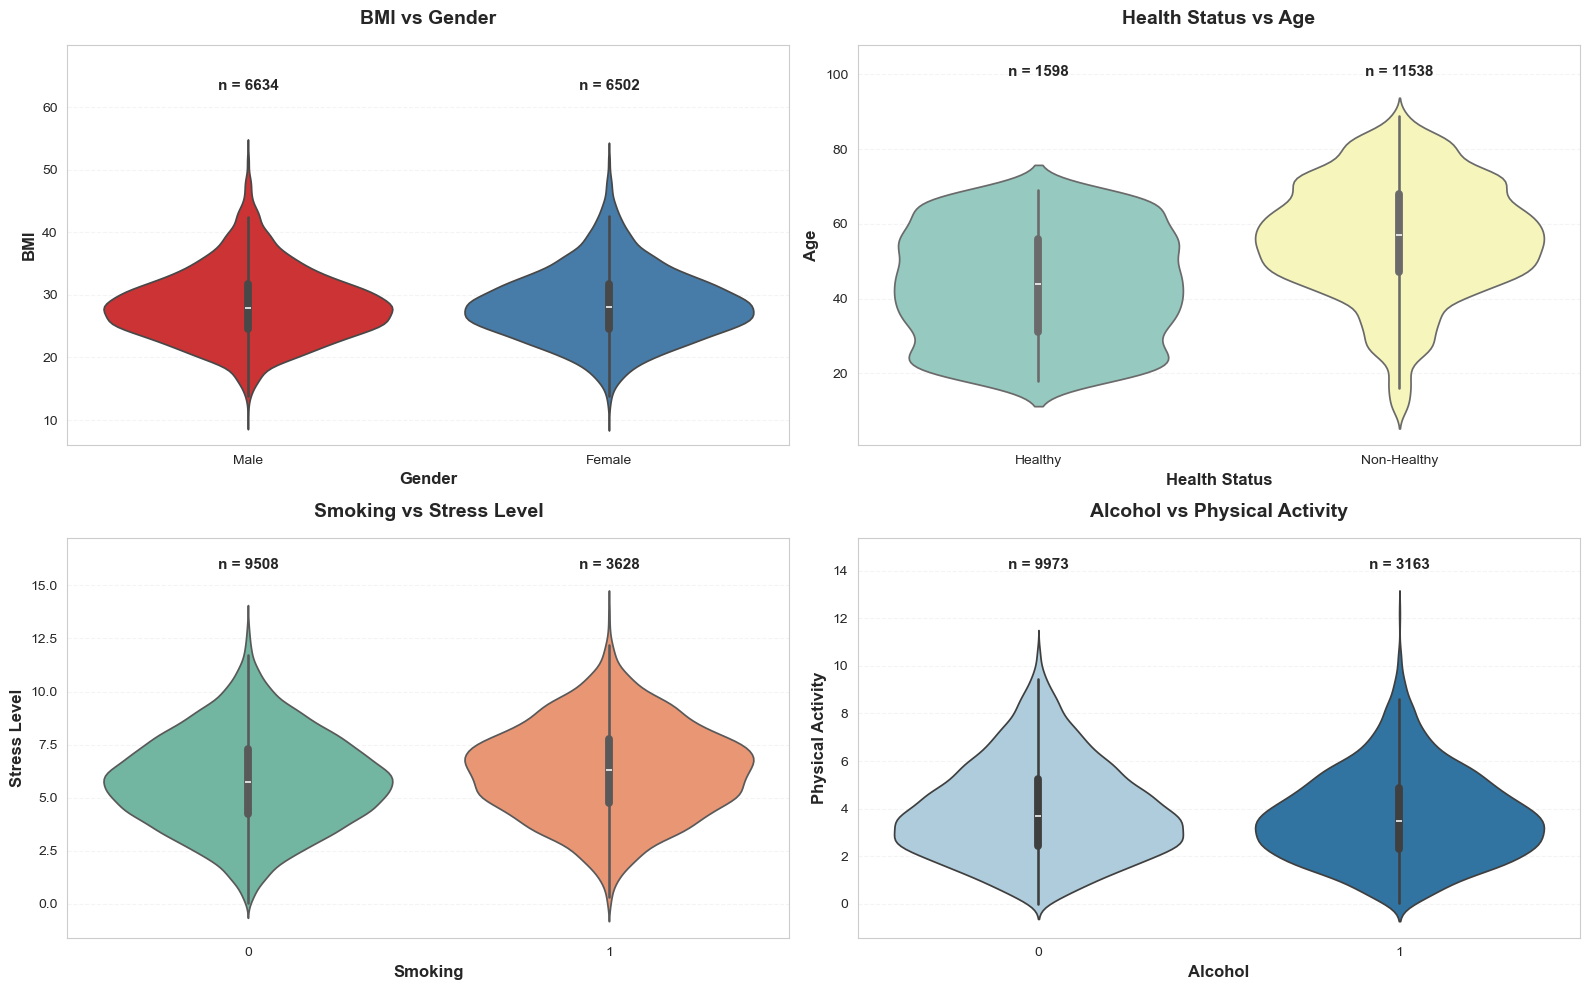

In [25]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

# 1. BMI vs Gender
ax = axes[0]

sns.violinplot(data=cleaned_df, x='Gender', y='BMI', inner='box', hue='Gender', palette='Set1', legend=False, ax=ax)

# Count
counts_gender = cleaned_df['Gender'].value_counts()

# Ylim
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
ax.set_ylim(y_min, y_max + 0.25 * y_range)

# Text position
y_text = y_max + 0.1 * y_range

# Labels
for i, category in enumerate(sorted(cleaned_df['Gender'].unique())):
    ax.text(i,y_text,f'n = {counts_gender[category]}',ha='center',va='bottom',fontsize=11,weight='bold')

ax.set_title('BMI vs Gender', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12, weight='bold')
ax.set_ylabel('BMI', fontsize=12, weight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')

# 2. Health Status vs Age
ax = axes[1]

sns.violinplot(data=cleaned_df,x='Health Status',y='Age',inner='box',hue='Health Status',palette='Set3',legend=False,ax=ax)

# Count
counts_health = cleaned_df['Health Status'].value_counts()

# Ylim
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
ax.set_ylim(y_min, y_max + 0.10 * y_range)

# Text position
y_text = y_max + 0.005 * y_range

# Labels
for i, category in enumerate(sorted(cleaned_df['Health Status'].unique())):
    ax.text(i,y_text,f'n = {counts_health[category]}',ha='center',va='bottom',fontsize=11,weight='bold')

ax.set_title('Health Status vs Age', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Health Status', fontsize=12, weight='bold')
ax.set_ylabel('Age', fontsize=12, weight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')

# 3. Smoking VS Stress level
ax = axes[2]

sns.violinplot(data=cleaned_df,x='Smoking',y='Stress Level',inner='box',palette='Set2',legend=True,ax=ax)

# Count
counts_health = cleaned_df['Smoking'].value_counts()

# Ylim
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
ax.set_ylim(y_min, y_max + 0.10 * y_range)

# Text position
y_text = y_max + 0.005 * y_range

# Labels
for i, category in enumerate(sorted(cleaned_df['Smoking'].unique())):
    ax.text(i,y_text,f'n = {counts_health[category]}',ha='center',va='bottom',fontsize=11,weight='bold')

ax.set_title('Smoking vs Stress Level', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Smoking', fontsize=12, weight='bold')
ax.set_ylabel('Stress Level', fontsize=12, weight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')


# 4. Smoking vs Sleep Hours
ax = axes[3]

sns.violinplot(data=cleaned_df,x='Alcohol',y='Physical Activity',inner='box',palette='Paired',legend=True,ax=ax)

# Count
counts_health = cleaned_df['Alcohol'].value_counts()

# Ylim
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
ax.set_ylim(y_min, y_max + 0.10 * y_range)

# Text position
y_text = y_max + 0.005 * y_range

# Labels
for i, category in enumerate(sorted(cleaned_df['Smoking'].unique())):
    ax.text(i,y_text,f'n = {counts_health[category]}',ha='center',va='bottom',fontsize=11,weight='bold')

ax.set_title('Alcohol vs Physical Activity', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Alcohol', fontsize=12, weight='bold')
ax.set_ylabel('Physical Activity', fontsize=12, weight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

Biomarkers 

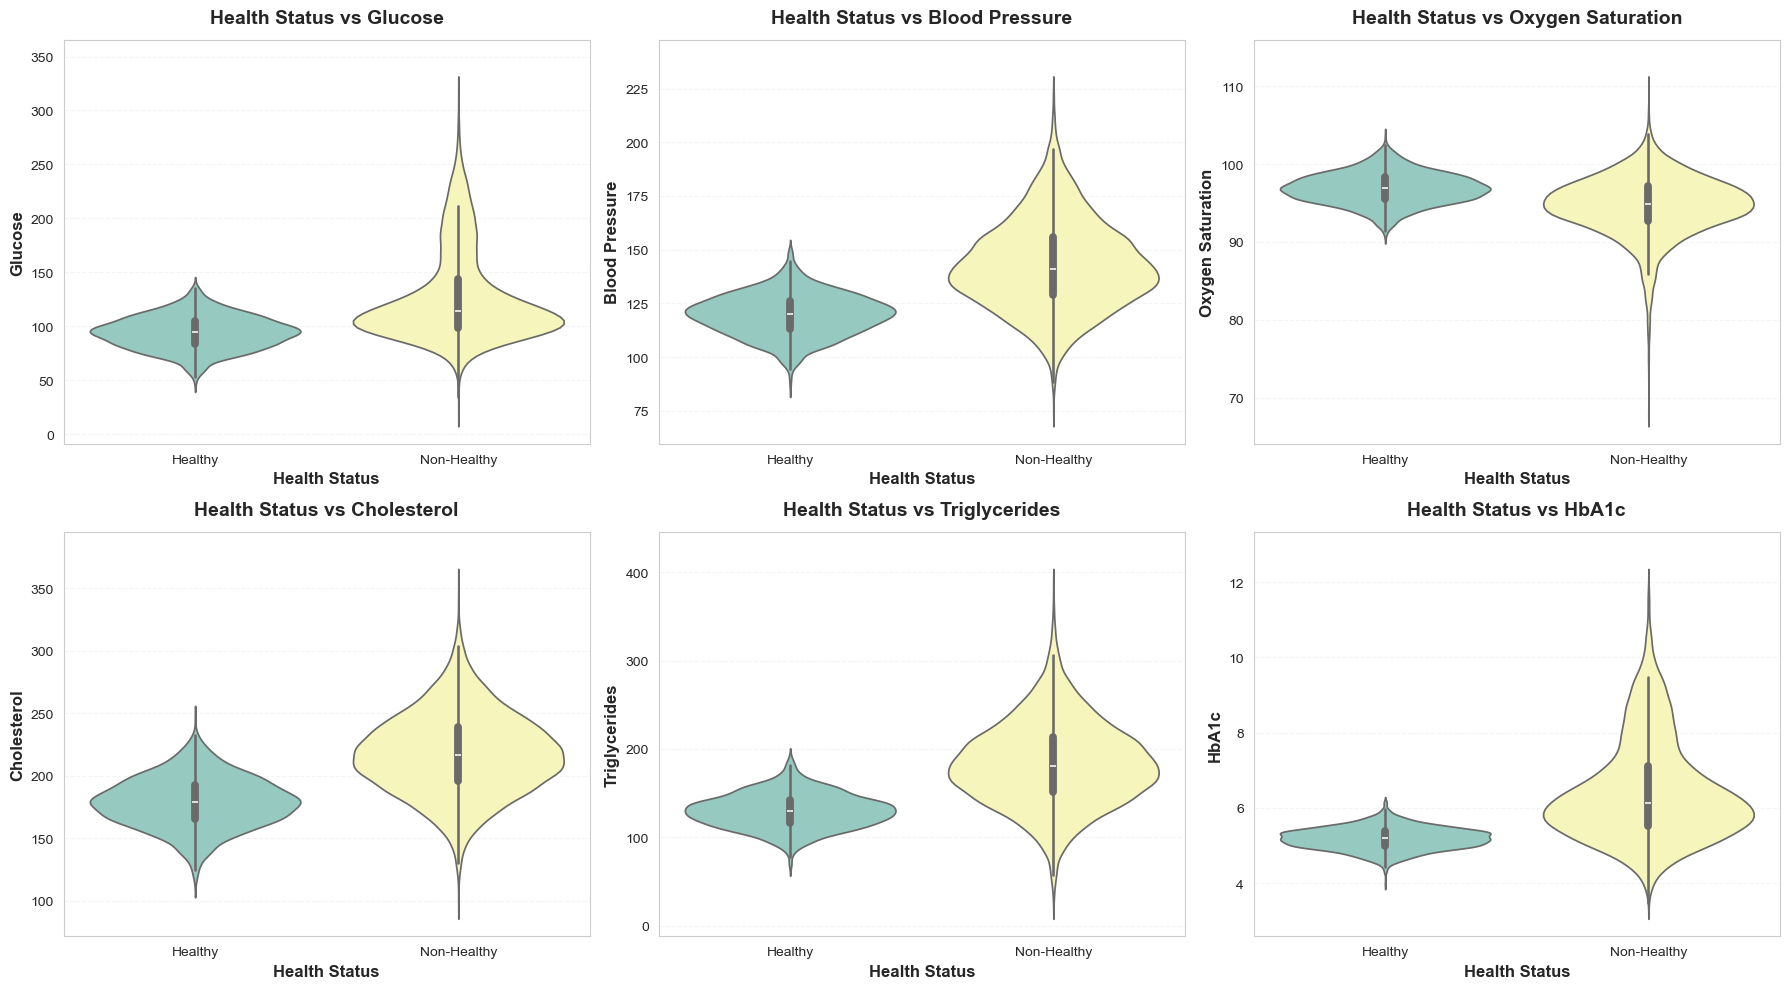

In [27]:
sns.set_style("whitegrid")

# Biomarkers
biomarkers = ['Glucose', 'Blood Pressure', 'Oxygen Saturation', 'Cholesterol', 'Triglycerides', 'HbA1c']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(biomarkers):
    ax = axes[i]
    
    sns.violinplot(
        data=cleaned_df,
        x='Health Status',
        y=col,
        inner='box',
        hue='Health Status',
        palette='Set3',
        legend=False,
        ax=ax
    )
    
    # Ylim
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + 0.05 * y_range)
    
    # Titles and labels
    ax.set_title(f'Health Status vs {col}', fontsize=14, weight='bold', pad=12)
    ax.set_xlabel('Health Status', fontsize=12, weight='bold')
    ax.set_ylabel(col, fontsize=12, weight='bold')
    ax.grid(axis='y', alpha=0.2, linestyle='--')

# Remove any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

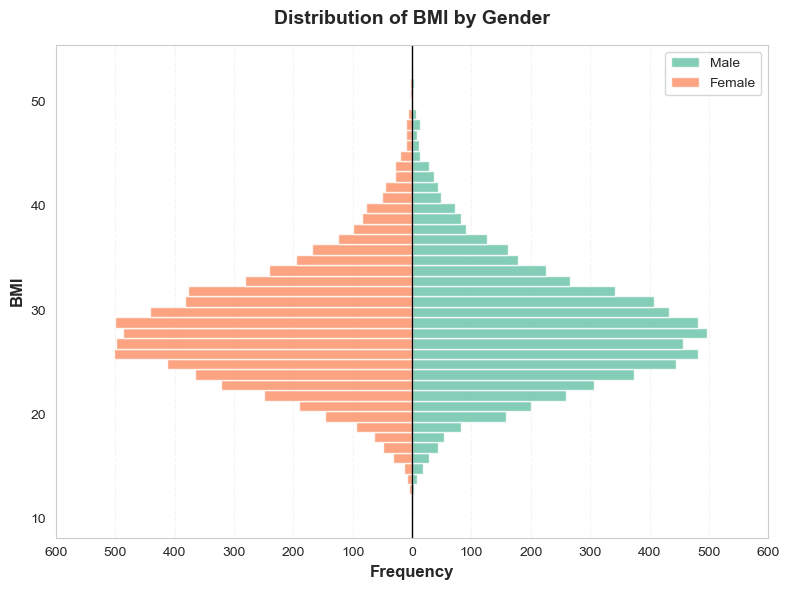

In [28]:
# Split data
male = cleaned_df[cleaned_df['Gender'] == 'Male']['BMI']
female = cleaned_df[cleaned_df['Gender'] == 'Female']['BMI']

# Set bins
bin_width = 1
bins = np.arange(
    min(cleaned_df['BMI']),
    max(cleaned_df['BMI']) + bin_width,
    bin_width
)

# Histogram
male_counts, bin_edges = np.histogram(male, bins=bins)
female_counts, _ = np.histogram(female, bins=bins)

# Bins centers = Y position
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Rounded maximum calculation
max_count = max(male_counts.max(), female_counts.max())
max_tick = int(np.ceil(max_count / 100.0) * 100)

fig, ax = plt.subplots(figsize=(8,6))

# Horizontal histograms 
ax.barh(bin_centers, male_counts,
        height=bin_width,
        color='#66c2a5',
        alpha=0.8,
        label='Male')

ax.barh(bin_centers, -female_counts,
        height=bin_width,
        color='#fc8d62',
        alpha=0.8,
        label='Female')

# Central lign
ax.axvline(0, color='black', linewidth=1)

ticks = np.arange(-max_tick, max_tick + 100, 100)
ax.set_xticks(ticks)
ax.set_xticklabels([abs(t) for t in ticks])

#Labels
ax.set_ylabel('BMI', fontsize=12, weight='bold')
ax.set_xlabel('Frequency', fontsize=12, weight='bold')
ax.set_title('Distribution of BMI by Gender', fontsize=14, weight='bold', pad=15)

# Legend
ax.legend()

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.2)
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

### Correlation Matrix 

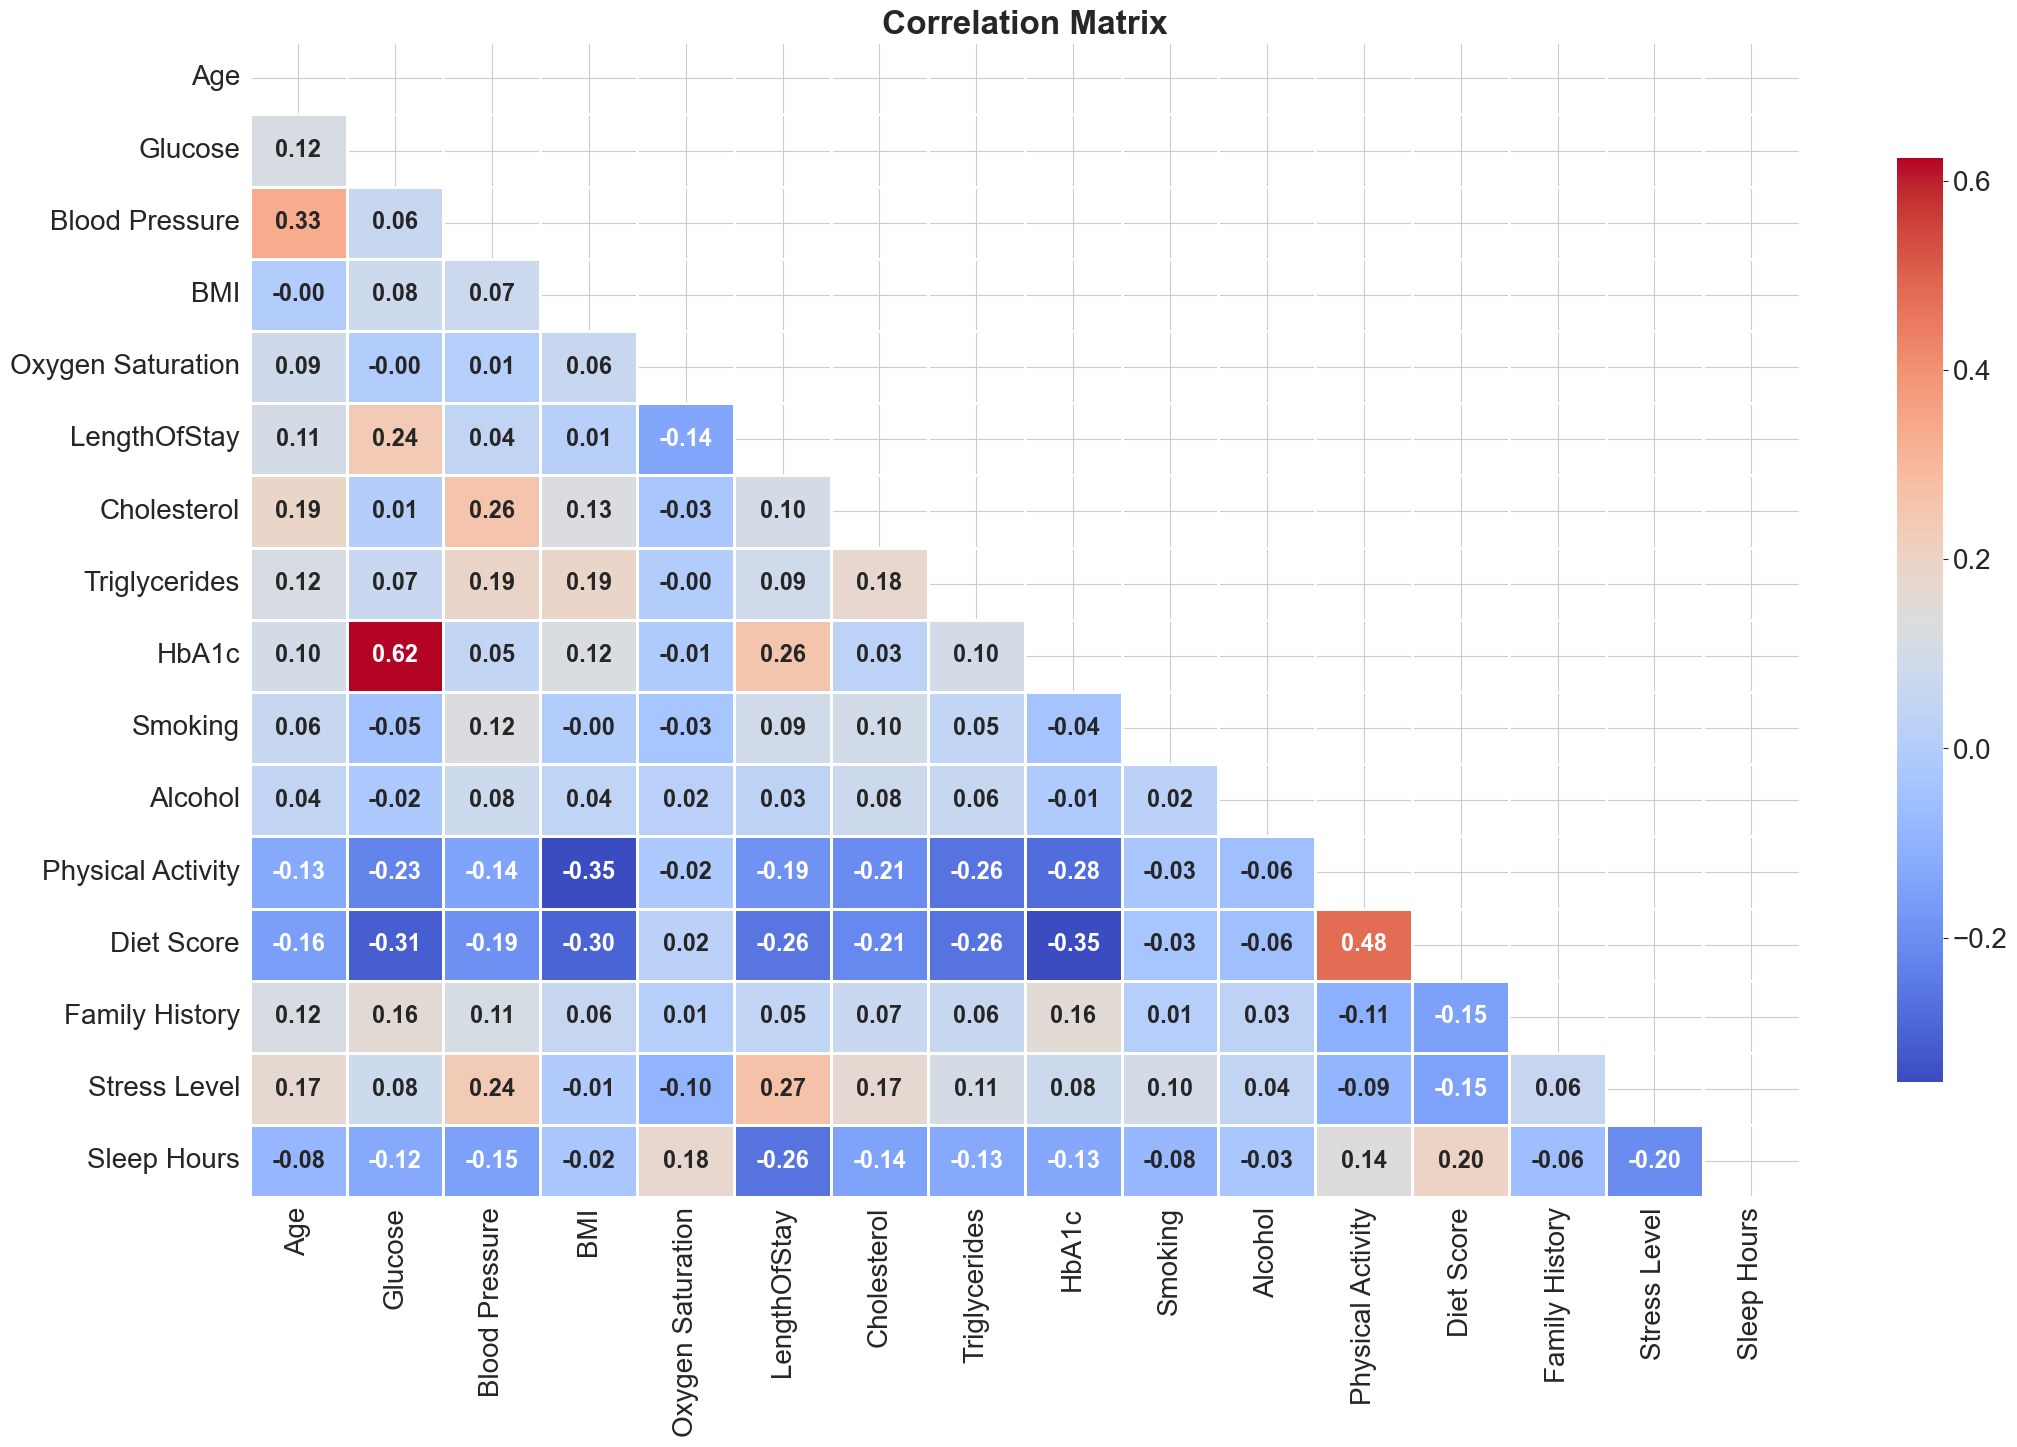

In [30]:
# Numeric variables selection
numeric = cleaned_df.select_dtypes(include=np.number)
# Correlation calculation
corr = numeric.corr(method='pearson')
# Mask for upper triangle 
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(25,15))
ax = sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',  fmt=".2f", annot_kws={"size":17, "weight":'bold'}, linewidth=.8, cbar_kws={"shrink": 0.8})

ax.tick_params(labelsize=20)
plt.title('Correlation Matrix', fontsize = 24, weight = 'bold')

# Increase labels font size in the colour bar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
plt.show()

## CV Risk Classification 

### Threshold Processing

In [33]:
labels = [0, 1]  # 0 = No risk, 1 = At risk
CV_df = pd.DataFrame()

# Biomarkers
CV_df['Glucose'] = cleaned_df['Glucose'].apply(lambda x: 1 if x >= 110 else 0)
CV_df['Blood Pressure'] = cleaned_df['Blood Pressure'].apply(lambda x: 1 if x >= 140 else 0)
CV_df['Oxygen Saturation'] = cleaned_df['Oxygen Saturation'].apply(lambda x: 1 if x < 90 else 0)  
CV_df['Cholesterol'] = cleaned_df['Cholesterol'].apply(lambda x: 1 if x >= 200 else 0)
CV_df['Triglycerides'] = cleaned_df['Triglycerides'].apply(lambda x: 1 if x >= 150 else 0)
CV_df['HbA1c'] = cleaned_df['HbA1c'].apply(lambda x: 1 if x >= 6 else 0)

# Lifestyle score metrics
CV_df['BMI'] = cleaned_df['BMI'].apply(lambda x: 1 if x < 18.5 or x > 25 else 0) 
CV_df['Physical Activity'] = cleaned_df['Physical Activity'].apply(lambda x: 1 if x < 2.5 else 0)  
CV_df['Sleep Hours'] = cleaned_df['Sleep Hours'].apply(lambda x: 1 if x < 7 else 0)  

threshold = cleaned_df['Diet Score'].quantile(0.25)
CV_df['Diet Score'] = cleaned_df['Diet Score'].apply(lambda x: 1 if x < threshold else 0)

CV_df[['Smoking', 'Alcohol']] = cleaned_df[['Smoking', 'Alcohol']]

CV_df.head(10)

,Glucose,Blood Pressure,Oxygen Saturation,Cholesterol,Triglycerides,HbA1c,BMI,Physical Activity,Sleep Hours,Diet Score,Smoking,Alcohol
1,0,0,0,0,0,0,1,0,0,0,0,0
4,0,1,0,1,0,0,1,0,1,0,0,1
5,0,1,0,1,1,0,1,0,1,0,1,0
9,0,0,0,0,1,1,1,0,1,0,1,0
11,1,0,0,0,0,0,0,0,0,0,1,0
13,0,0,0,0,1,0,1,0,0,0,1,0
14,0,0,0,0,1,0,1,0,1,0,1,1
16,1,0,1,0,0,1,1,0,1,1,1,1
17,1,1,0,1,0,1,1,1,1,0,0,1
21,1,0,0,1,1,0,1,1,1,0,1,0


### Threshold Vizualisation

In [35]:
# Fractions calculatioh
prop_df = CV_df.apply(lambda x: x.value_counts(normalize=True)).T

# Rename for more clarity
prop_df.columns = ['Healthy (0)', 'At Risk (1)']

print(prop_df)

                   Healthy (0)  At Risk (1)
Glucose               0.493681     0.506319
Blood Pressure        0.535780     0.464220
Oxygen Saturation     0.914357     0.085643
Cholesterol           0.363733     0.636267
Triglycerides         0.315469     0.684531
HbA1c                 0.512789     0.487211
BMI                   0.251751     0.748249
Physical Activity     0.731806     0.268194
Sleep Hours           0.269945     0.730055
Diet Score            0.750457     0.249543
Smoking               0.723812     0.276188
Alcohol               0.759211     0.240789


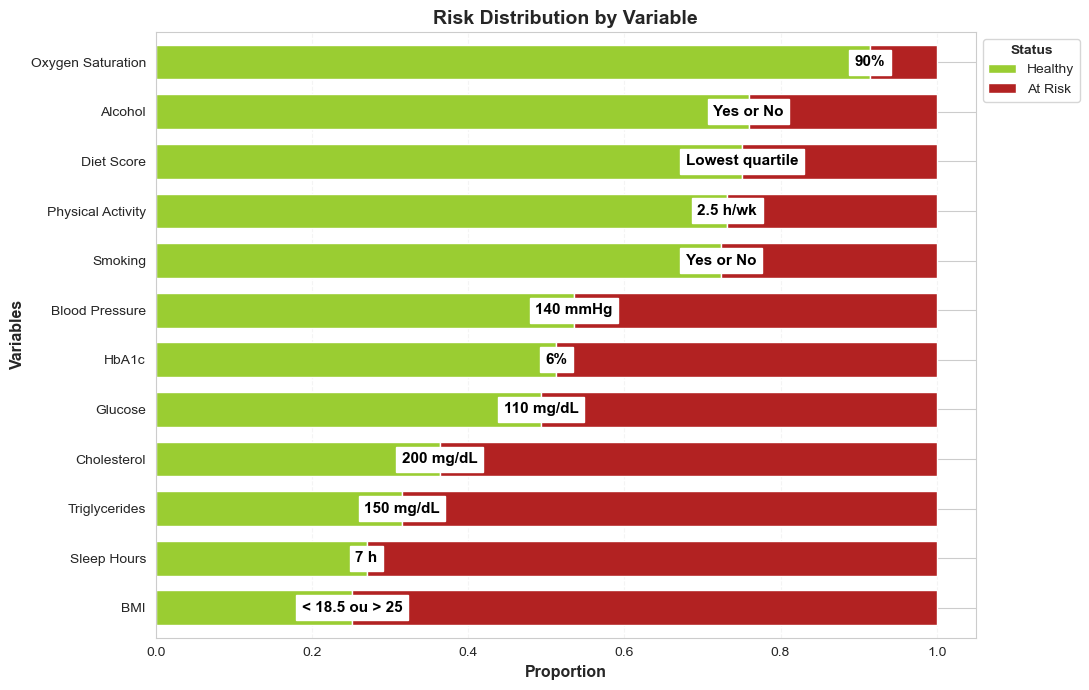

In [36]:
thresholds = {
    'Glucose': '110 mg/dL',
    'Blood Pressure': '140 mmHg',
    'BMI': '< 18.5 ou > 25',
    'Oxygen Saturation': '90%',
    'Cholesterol': '200 mg/dL',
    'Triglycerides': '150 mg/dL',
    'HbA1c': '6%',
    'Physical Activity': '2.5 h/wk',
    'Diet Score': 'Lowest quartile',
    'Sleep Hours': '7 h',
    'Smoking':'Yes or No',
    'Alcohol':'Yes or No'
}

# Sort by descending risk
prop_df_sorted = prop_df.sort_values(by='At Risk (1)', ascending=False)

prop_df_sorted.plot(kind='barh',
                    stacked=True,
                    figsize=(11,7),
                    color=['yellowgreen', 'firebrick'],
                    width=0.7)

# Add labels to bars
for i, var in enumerate(prop_df_sorted.index):
    healthy_prop = prop_df_sorted.loc[var, 'Healthy (0)']  # proportion "Healthy"
    threshold_text = thresholds[var]                      # Threshold text
    plt.text(healthy_prop, i, threshold_text,
            va='center', ha='center', fontsize=11, weight='bold', color='black', backgroundcolor='white')

plt.title('Risk Distribution by Variable', fontsize=14, weight='bold')
plt.xlabel('Proportion', weight = 'bold', fontsize = 11.5)
plt.ylabel('Variables', weight = 'bold', fontsize = 11.5)

plt.legend(labels=['Healthy', 'At Risk'], title='Status', loc = 'upper left', bbox_to_anchor=(1, 1)).get_title().set_fontweight('bold')
plt.grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

### Classification Processing 

In [38]:
biomarkers = ['Glucose','Blood Pressure','Oxygen Saturation','Cholesterol','Triglycerides','HbA1c']

CV_df['CV Risk Score'] = CV_df[biomarkers].sum(axis=1)

def classify_risk(x):
    if x  < 2:
        return 'low'   # 'Low' class => 0 or 1 factor
    elif 2 <= x <= 3:
        return 'moderate'  # 'Moderate' class => 2 or 3 factors
    else:
        return 'high'  # 'High' class => > 3 factors

CV_df['CV Risk Class'] = CV_df['CV Risk Score'].apply(classify_risk)
CV_df[['CV Risk Score','CV Risk Class']].head(10)

,CV Risk Score,CV Risk Class
1,0,low
4,2,moderate
5,3,moderate
9,2,moderate
11,1,low
13,1,low
14,1,low
16,3,moderate
17,4,high
21,3,moderate


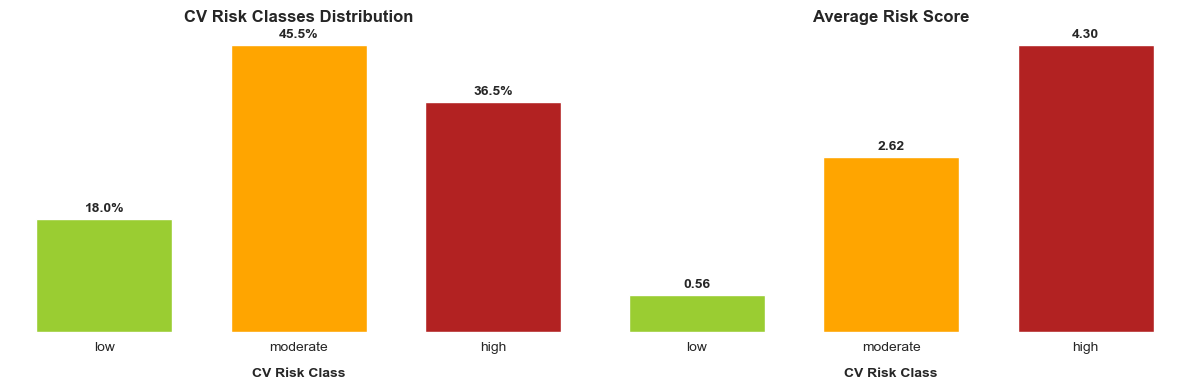

In [39]:
dist = CV_df['CV Risk Class'].value_counts(normalize=True)
dist = dist.loc[['low', 'moderate', 'high']]

mean_score = CV_df.groupby('CV Risk Class')['CV Risk Score'].mean()
mean_score = mean_score.loc[['low', 'moderate', 'high']]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
colors = ['yellowgreen', 'orange', 'firebrick']

# 1- Distribution
ax = axes[0]
bars = ax.bar(dist.index, dist.values, color=colors, width=0.7)

# Labels
for i, v in enumerate(dist):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')

ax.set_title('CV Risk Classes Distribution', weight='bold')
ax.set_xlabel('CV Risk Class', labelpad=10, weight = 'bold')
axes[0].set_yticks([])


# Clean the grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)


# 2- Mean Risk Score 
ax = axes[1]
bars = ax.bar(mean_score.index, mean_score.values, color=colors, width=0.7)

for i, v in enumerate(mean_score):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

ax.set_title('Average Risk Score', weight='bold')
ax.set_xlabel('CV Risk Class', labelpad=10, weight = 'bold')
axes[1].set_yticks([])


# Clean the grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Classification Profile

In [41]:
cleaned_df.groupby(CV_df['CV Risk Class'])[biomarkers].mean()

,Glucose,Blood Pressure,Oxygen Saturation,Cholesterol,Triglycerides,HbA1c
CV Risk Class,,,,,,
high,147.052116,150.120803,94.548384,226.767623,194.198553,7.032208
low,95.008734,122.619496,96.248573,183.491452,135.993802,5.271888
moderate,115.640597,139.295228,94.691308,213.388060,179.076186,6.087832


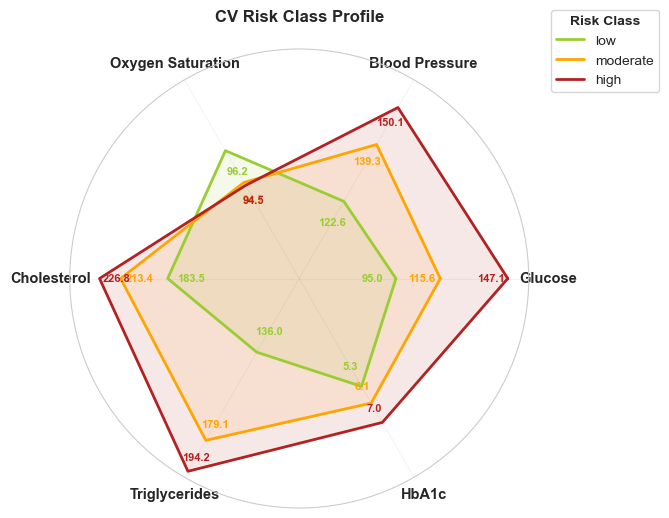

In [42]:
# Means per risk classes 
profile = cleaned_df.groupby(CV_df['CV Risk Class'])[biomarkers].mean()
profile = profile.loc[['low', 'moderate', 'high']]

labels = biomarkers
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

# Min/max per biomarker for radial scale
radial_limits = {
    'Glucose': (50, 160),
    'Blood Pressure': (100, 160),
    'Oxygen Saturation': (90, 100),
    'Cholesterol': (100, 250),
    'Triglycerides': (100, 200),
    'HbA1c': (0, 10)
}

# Offets preventing from overlapping labels
offsets = {'low': -0.1, 'moderate': -0.08, 'high': -0.07}

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
colors = {'low':'yellowgreen','moderate':'orange','high':'firebrick'}

for risk_class in profile.index:
    values = []
    for col in profile.columns:
        min_val, max_val = radial_limits[col]
        v = (profile.loc[risk_class, col] - min_val) / (max_val - min_val)
        values.append(v)
    values += values[:1]

    ax.plot(angles, values, label=risk_class, color=colors[risk_class], linewidth=2)
    ax.fill(angles, values, color=colors[risk_class], alpha=0.1)

    # Add labels with offsets
    for angle, col, val in zip(angles[:-1], profile.columns, profile.loc[risk_class]):
        rad = (val - radial_limits[col][0]) / (radial_limits[col][1] - radial_limits[col][0])
        ax.text(angle, rad + offsets[risk_class],
                f"{val:.1f}", 
                color=colors[risk_class], fontsize=8, ha='center', va='center', weight='bold')

# Labekls axes  
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10.5, weight='bold')

# Drop radial ticks ticks
ax.set_yticks([])

ax.set_title('CV Risk Class Profile', weight='bold', pad=20)
ax.grid(alpha=0.2)
plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), title='Risk Class').get_title().set_fontweight('bold')
plt.tight_layout()
plt.show()

## Lifestyle Classification 

### Classification Processing 

In [45]:
lifestyle = ['BMI','Physical Activity', 'Diet Score', 'Sleep Hours','Smoking','Alcohol']

CV_df['Lifestyle Score'] = CV_df[lifestyle].sum(axis=1)

def classify_risk(x):
    if x  <= 1:
        return 'low'   # 'Low' class => 0 or 1 factor
    elif x == 2 :
        return 'moderate'  # 'Moderate' class => 2 factors
    else:
        return 'high'  # 'High' class => > 2 factors

CV_df['Lifestyle Class'] = CV_df['Lifestyle Score'].apply(classify_risk)
CV_df[['Lifestyle Score','Lifestyle Class']].head(10)

,Lifestyle Score,Lifestyle Class
1,1,low
4,3,high
5,3,high
9,3,high
11,1,low
13,2,moderate
14,4,high
16,5,high
17,4,high
21,4,high


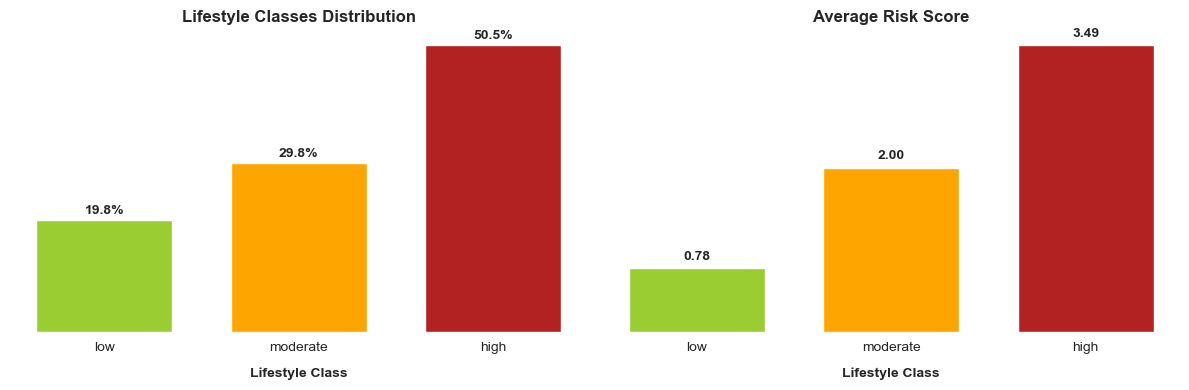

In [46]:
# Data
dist = CV_df['Lifestyle Class'].value_counts(normalize=True)
dist = dist.loc[['low', 'moderate', 'high']]

mean_score = CV_df.groupby('Lifestyle Class')['Lifestyle Score'].mean()
mean_score = mean_score.loc[['low', 'moderate', 'high']]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
colors = ['yellowgreen', 'orange', 'firebrick']

# 1- Distribution
ax = axes[0]
bars = ax.bar(dist.index, dist.values, color=colors, width=0.7)

# Labels
for i, v in enumerate(dist):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')

ax.set_title('Lifestyle Classes Distribution', weight='bold')
ax.set_xlabel('Lifestyle Class', labelpad=10, weight = 'bold')
axes[0].set_yticks([])

# Clean the grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)


# 2- Mean Risk Score 
ax = axes[1]
bars = ax.bar(mean_score.index, mean_score.values, color=colors, width=0.7)

for i, v in enumerate(mean_score):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

ax.set_title('Average Risk Score', weight='bold')
ax.set_xlabel('Lifestyle Class', labelpad=10, weight = 'bold')
axes[1].set_yticks([])


# Clean the grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Classification Profile

In [48]:
cleaned_df.groupby(CV_df['Lifestyle Class'])[lifestyle].mean()

,BMI,Physical Activity,Diet Score,Sleep Hours,Smoking,Alcohol
Lifestyle Class,,,,,,
high,30.383269,3.063364,3.311283,5.917934,0.431242,0.380277
low,24.289164,5.549465,5.595254,7.130909,0.041602,0.049307
moderate,27.897817,4.144898,4.331786,6.212390,0.168884,0.131269


C:\Users\33638\AppData\Local\Temp\ipykernel_13876\2166035201.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_multiline, fontsize=9, weight='bold')


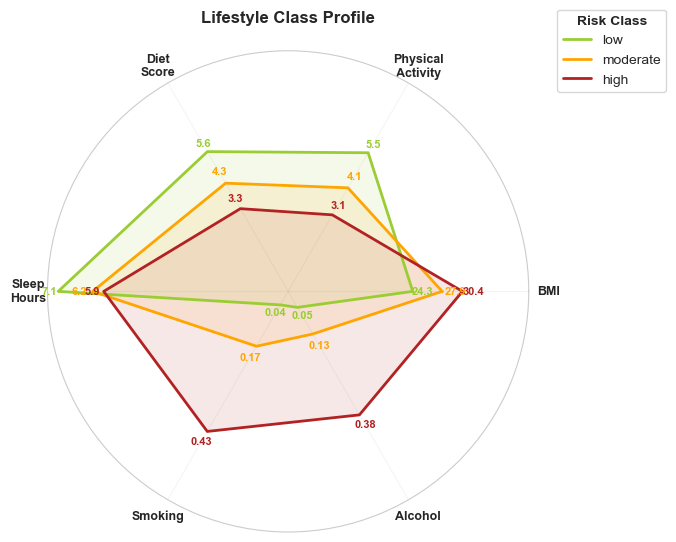

In [49]:
# Means per risk classes
profile = cleaned_df.groupby(CV_df['Lifestyle Class'])[lifestyle].mean()
profile = profile.loc[['low', 'moderate', 'high']]

labels = lifestyle
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

# Min/max per biomarker for radial scale
radial_limits = {
    'BMI': (9, 55),
    'Physical Activity': (0, 13),
    'Diet Score':(0,13),
    'Sleep Hours': (1, 11),
    'Smoking': (0, 1),
    'Alcohol': (0, 1)
}

# Offsets preventinf from overlapping labels 
offsets = {'low': 0.025, 'moderate': 0.035, 'high': 0.03}

# --- Figure ---
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

colors = {'low':'yellowgreen','moderate':'orange','high':'firebrick'}

for risk_class in profile.index:
    values = []
    for col in profile.columns:
        min_val, max_val = radial_limits[col]
        # proportion radiale 0->1 pour cet axe
        v = (profile.loc[risk_class, col] - min_val) / (max_val - min_val)
        values.append(v)
    values += values[:1]

    ax.plot(angles, values, label=risk_class, color=colors[risk_class], linewidth=2)
    ax.fill(angles, values, color=colors[risk_class], alpha=0.1)

   # Add labels with offsets
    for angle, col, val in zip(angles[:-1], profile.columns, profile.loc[risk_class]):
        min_val, max_val = radial_limits[col]
        rad = (val - min_val) / (max_val - min_val)

        # Specific format for labels
        if col in ['Smoking', 'Alcohol']:
            text_val = f"{val:.2f}"
        else:
            text_val = f"{val:.1f}"

        ax.text(angle,
                rad + offsets[risk_class],
                text_val,
                color=colors[risk_class],
                fontsize=8,
                ha='center',
                va='center',
                weight='bold')

# Labels axes 
labels_multiline = [label.replace(' ', '\n') for label in labels]
ax.set_xticklabels(labels_multiline, fontsize=9, weight='bold')
ax.set_xticks(angles[:-1])

# Drop radial ticks
ax.set_yticks([])

ax.set_title('Lifestyle Class Profile', weight='bold', pad=20)
ax.grid(alpha=0.2)
plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), title='Risk Class').get_title().set_fontweight('bold')
plt.tight_layout()
plt.show()

## Joint Associations 

### Lifestyle and CV Risk 

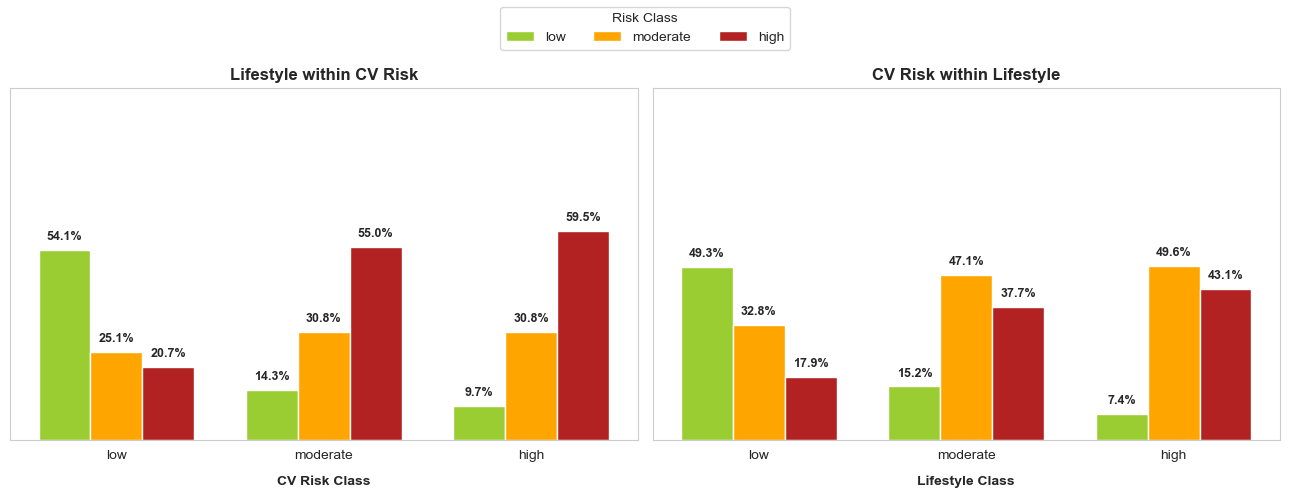

In [52]:
ct_cv = pd.crosstab(CV_df['CV Risk Class'], 
                    CV_df['Lifestyle Class'], 
                    normalize='index')

ct_lifestyle = pd.crosstab(CV_df['Lifestyle Class'], 
                           CV_df['CV Risk Class'], 
                           normalize='index')

order = ['low', 'moderate', 'high']
ct_cv = ct_cv.loc[order, order]
ct_lifestyle = ct_lifestyle.loc[order, order]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
colors = ['yellowgreen','orange','firebrick']
x = np.arange(len(order))
width = 0.25

# 1- Lifestyle within CV
for i, col in enumerate(ct_cv.columns):
    bars = axes[0].bar(x + (i-1)*width,
                       ct_cv[col],
                       width,
                       label=col,
                       color=colors[i])
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     height + 0.02,
                     f"{height*100:.1f}%",
                     ha='center', va='bottom', fontsize=9, weight='bold')

axes[0].set_title('Lifestyle within CV Risk', weight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order)
axes[0].set_xlabel('CV Risk Class', weight='bold', labelpad=10)
axes[0].set_ylim(0,1)
axes[0].grid(False)

# Drop Y axis
axes[0].set_yticks([])

# 2- CV within Lifestyle
for i, col in enumerate(ct_lifestyle.columns):
    bars = axes[1].bar(x + (i-1)*width,
                       ct_lifestyle[col],
                       width,
                       label=col,
                       color=colors[i])
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     height + 0.02,
                     f"{height*100:.1f}%",
                     ha='center', va='bottom', fontsize=9, weight='bold')

axes[1].set_title('CV Risk within Lifestyle', weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order)
axes[1].set_xlabel('Lifestyle Class', weight='bold', labelpad=10)
axes[1].set_ylim(0,1)
axes[1].grid(False)
axes[1].set_yticks([])

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=3,
           title='Risk Class')


# 6) Clean the grid
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

### Health Status and Risk Scores

In [54]:
CV_df[['Health Status']] = cleaned_df[['Health Status']]
CV_df.head()

,Glucose,Blood Pressure,Oxygen Saturation,Cholesterol,Triglycerides,HbA1c,BMI,Physical Activity,Sleep Hours,Diet Score,Smoking,Alcohol,CV Risk Score,CV Risk Class,Lifestyle Score,Lifestyle Class,Health Status
1,0,0,0,0,0,0,1,0,0,0,0,0,0,low,1,low,Healthy
4,0,1,0,1,0,0,1,0,1,0,0,1,2,moderate,3,high,Non-Healthy
5,0,1,0,1,1,0,1,0,1,0,1,0,3,moderate,3,high,Non-Healthy
9,0,0,0,0,1,1,1,0,1,0,1,0,2,moderate,3,high,Non-Healthy
11,1,0,0,0,0,0,0,0,0,0,1,0,1,low,1,low,Healthy


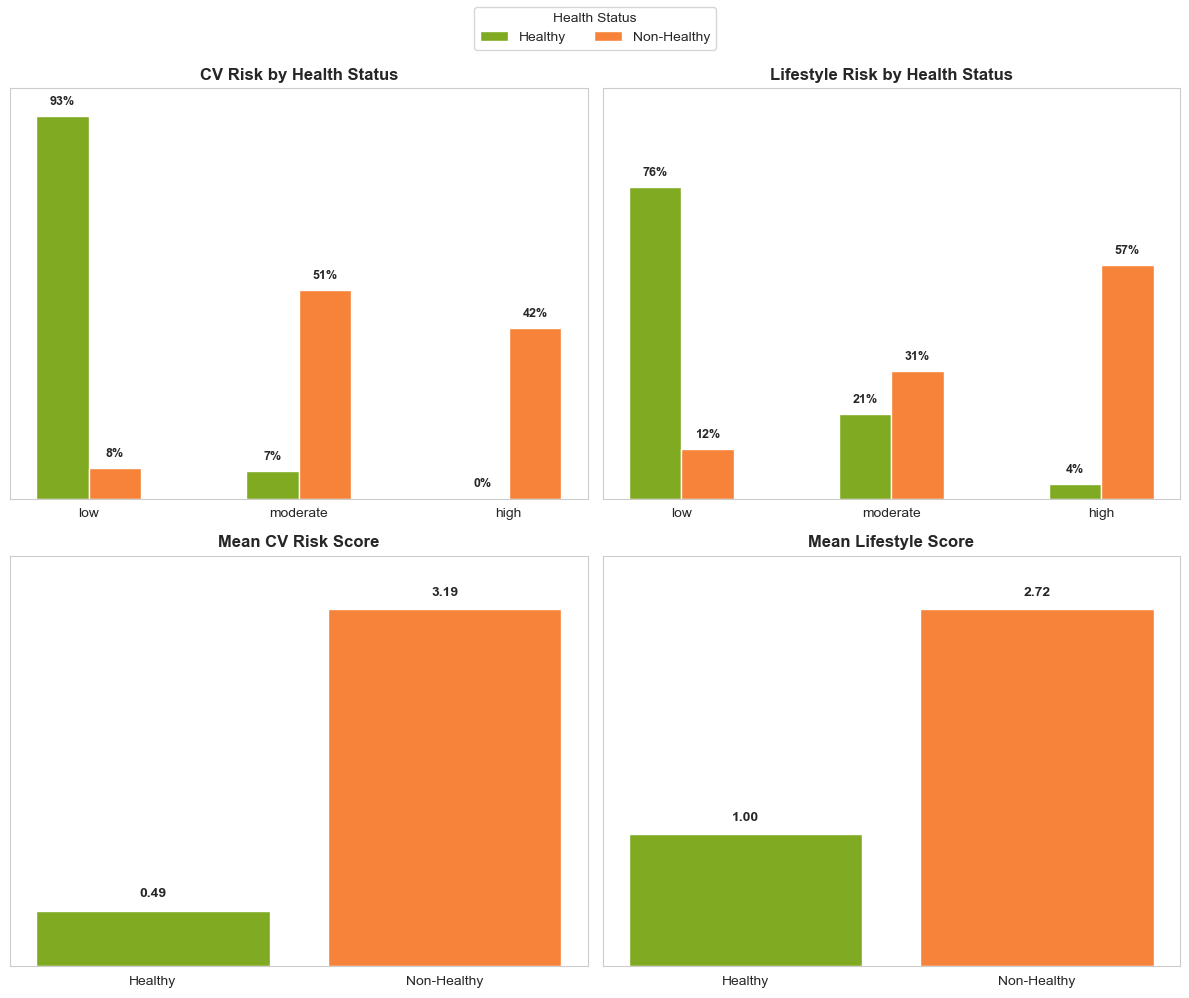

In [55]:
ct_cv_health = pd.crosstab(CV_df['Health Status'],
                          CV_df['CV Risk Class'],
                          normalize='index')

ct_lifestyle_health = pd.crosstab(CV_df['Health Status'],
                                 CV_df['Lifestyle Class'],
                                 normalize='index')

order = ['low','moderate','high']
ct_cv_health = ct_cv_health[order]
ct_lifestyle_health = ct_lifestyle_health[order]

# Means calculation
cv_mean = CV_df.groupby('Health Status')['CV Risk Score'].mean()
lifestyle_mean = CV_df.groupby('Health Status')['Lifestyle Score'].mean()


fig, axes = plt.subplots(2, 2, figsize=(12,10))
color_map = {'Healthy': '#80AA22', 'Non-Healthy': '#F7833B'}

x = np.arange(len(order))
width = 0.25

# 1- CV Risk by Health Status
for i, health_group in enumerate(ct_cv_health.index):
    bars = axes[0,0].bar(x + (i-0.5)*width,
                         ct_cv_health.loc[health_group],
                         width,
                         label=health_group, 
                         color=color_map[health_group])
                        
    
    for bar in bars:
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2,
                       height + 0.02,
                       f"{height*100:.0f}%",
                       ha='center', va='bottom', fontsize=9, weight='bold')

axes[0,0].set_title('CV Risk by Health Status', weight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(order)
axes[0,0].set_ylim(0,1)
axes[0,0].set_yticks([])
axes[0,0].grid(False)

# 2- Lifestyle by Health Status
for i, health_group in enumerate(ct_lifestyle_health.index):
    bars = axes[0,1].bar(x + (i-0.5)*width,
                         ct_lifestyle_health.loc[health_group],
                         width,
                         label=health_group,
                         color=color_map[health_group])
    
    for bar in bars:
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2,
                       height + 0.02,
                       f"{height*100:.0f}%",
                       ha='center', va='bottom', fontsize=9, weight='bold')

axes[0,1].set_title('Lifestyle Risk by Health Status', weight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(order)
axes[0,1].set_ylim(0,1)
axes[0,1].set_yticks([])
axes[0,1].grid(False)

# 3- Mean CV Risk Score
bars1 = axes[1,0].bar(cv_mean.index, cv_mean.values,  color=[color_map[g] for g in cv_mean.index])

ymax_cv = cv_mean.max()

for bar in bars1:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   height + ymax_cv*0.03,   # proportional offset 
                   f"{height:.2f}",
                   ha='center', va='bottom', weight='bold')

axes[1,0].set_title('Mean CV Risk Score', weight='bold')
axes[1,0].set_ylim(0, ymax_cv * 1.15)  # add blank on top
axes[1,0].set_yticks([])
axes[1,0].grid(False)

# 4- Mean Lifestyle Score
bars2 = axes[1,1].bar(lifestyle_mean.index, lifestyle_mean.values,  color=[color_map[g] for g in lifestyle_mean.index])
ymax_ls = lifestyle_mean.max()

for bar in bars2:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   height + ymax_ls*0.03,
                   f"{height:.2f}",
                   ha='center', va='bottom', weight='bold')

axes[1,1].set_title('Mean Lifestyle Score', weight='bold')
axes[1,1].set_ylim(0, ymax_ls * 1.15)
axes[1,1].set_yticks([])
axes[1,1].grid(False)

# Legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=2,
           title='Health Status')

# Drop local legends
axes[0,0].legend().remove()
axes[0,1].legend().remove()

# Clean the grid
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Test du Khi-Deux

(Statistical test used to measure categorical variables association)

In [58]:
from scipy.stats import chi2_contingency

# Crossed table between CV Risk and Health Status
table1 = pd.crosstab(CV_df['Health Status'], CV_df['CV Risk Class'])

chi2, p, dof, expected = chi2_contingency(table1)

print("Chi² =", chi2)
print("p-value =", p)
print("Degrees of liberty =", dof)
print("Expected frequencies :\n", expected)

# Interpretation
alpha = 0.05
if p < alpha:
    print("Dependent variables : significant difference")
else:
    print("Independent variables : no significant difference")

Chi² = 7018.434433801342
p-value = 0.0
Degrees of liberty = 2
Expected frequencies :
 [[ 583.43544458  287.33830694  727.22624848]
 [4212.56455542 2074.66169306 5250.77375152]]
Dependent variables : significant difference


In [59]:
# Crossed table between CV Risk and Lifestyle
ct = pd.crosstab(CV_df['CV Risk Class'], CV_df['Lifestyle Class'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi² =", chi2)
print("p-value =", p)
print("Degrees of liberty =", dof)
print("Expected frequencies :\n", expected)

# Interpretation
alpha = 0.05
if p < alpha:
    print(" Dependent variables : significant difference")
else:
    print("Variables Independent variables : No significant difference")

Chi² = 2288.52149985135
p-value = 0.0
Degrees of liberty = 4
Expected frequencies :
 [[2421.36662607  947.80876979 1426.82460414]
 [1192.50791717  466.78989038  702.70219245]
 [3018.12545676 1181.40133983 1778.47320341]]
 Dependent variables : significant difference
